# Lazy loading & chunking

This notebook shows how to open large multi-year HYCOM archives without loading field data into memory, explains why the task graph can itself become expensive, and presents two practical remedies.

We use the `memory_profiler` extension throughout:

- `%%time` reports wall-clock and CPU time.
- `%%memit` reports **peak memory** and **increment** (memory added on top of what was already in use).

In [1]:
import xhycom

Set the paths below to point at your data before running.

In [2]:
GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"  # directory containing archv.*.ab or archm.*.ab

## Open a time series

Pass a directory or a glob pattern and xhycom discovers all matching `.ab` file pairs, parses their `.b` headers, and returns a single Dataset with a `time` dimension spanning every snapshot in chronological order.

To understand the memory and time cost of each approach, we use the `memory_profiler` extension:

- `%%time` reports wall-clock and CPU time for the cell.
- `%%memit` reports **peak memory** (the high-water mark reached during the cell) and **increment** (how much extra memory was allocated on top of what was already in use before the cell ran).

We start by opening the first 9 daily files of 2020 **without** chunking, so all field data is read eagerly into RAM.

In [3]:
%load_ext memory_profiler

In [4]:
%%time
%%memit
ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020_00*", grid=GRID_PATH)

peak memory: 54543.73 MiB, increment: 54424.82 MiB
CPU times: user 16 s, sys: 5.79 s, total: 21.8 s
Wall time: 1min 14s


The output tells us two things:

- **Increment: ~54 GB** — xhycom read every `.a` binary file in full and allocated one array per variable per time step. With only 9 files and 83 variables this is already enormous; a full year would consume hundreds of GB, and a multi-decade archive would be completely unworkable.
- **Wall time: ~26 s** — the call blocked for 26 seconds while all that data was transferred from disk into RAM.

:::{note}
`%%time` and `%%memit` are optional. Remove them from any cell if you are not interested in the profiling output — they have no effect on the returned data.
:::

In [5]:
ds

<xarray.Dataset> Size: 29GB
Dimensions:     (time: 9, y: 380, x: 400, k: 50, ki: 51)
Coordinates:
  * time        (time) object 72B 2020-01-01 00:00:00 ... 2020-01-09 00:00:00
    lon         (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat         (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u       (y, x) float64 1MB -94.83 -94.67 -94.5 ... 99.16 99.02 98.89
    lat_u       (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v       (y, x) float64 1MB -94.68 -94.52 -94.35 ... 99.0 98.87 98.74
    lat_v       (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B 0.1 0.2 0.3 0.4 0.5 ... 28.09 28.1 28.11 28.12
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    srfhgt      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    oneta       (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    wtrflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    salflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    ...          ...
    CO2_wind    (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    ECO_bots    (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surface__1  (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surface__2  (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    si_u        (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    si_v        (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

## Lazy loading with Dask

The fix is the `chunks` argument. With `chunks={"time": 1}`, xhycom does **not** read the `.a` binary files at open time. Instead it:

1. Parses only the lightweight `.b` text headers — one per file — to learn field names, layer structure, and timestamps.
2. Builds a [Dask](https://docs.dask.org) computation graph: a recipe that describes *how* to read each array when values are eventually needed.
3. Returns a Dataset whose data variables carry `dask.array` instead of actual numbers.

Nothing is read from disk until you explicitly ask for values via `.compute()`, `.load()`, or `.plot()`.

Other useful chunk strategies:

| `chunks=` | When to use |
|-----------|-------------|
| `{"time": 1}` | Long time series; process one snapshot at a time (most common) |
| `{"k": 1}` | Depth-by-depth analysis within a single snapshot |
| `{"time": 1, "k": 1}` | Layer-by-layer pass over a long time series |

In [6]:
%%time
%%memit
ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.2020_00*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 27806.80 MiB, increment: 87.84 MiB
CPU times: user 302 ms, sys: 82.7 ms, total: 384 ms
Wall time: 502 ms


The contrast with the eager approach is stark:

- **Increment: 130 MB** instead of ~54 GB — xhycom only parsed the small `.b` text headers; no binary data was read.
- **Wall time: 678 ms** instead of ~26 s — headers for all 9 files were parsed in parallel.

The Dataset header reports `Size: 29 GB` because that is how large the data *would be* if fully loaded. Right now, virtually none of it is in RAM.

In [7]:
ds_lazy   # DataArrays show 'dask.array' — nothing read yet

<xarray.Dataset> Size: 29GB
Dimensions:     (y: 380, x: 400, time: 9, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 72B 2020-01-01 00:00:00 ... 2020-01-09 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

In [8]:
smean = ds_lazy["salin"].isel(k=0).mean("time")
smean

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

`smean` is still a Dask array — the chain `.isel(k=0).mean("time")` has been *scheduled* but not yet executed. Dask simply extended the computation graph: it now describes "read surface salinity from each of the 9 files and average them." Nothing has been read from disk yet.

In [9]:
%%time
%%memit

smean.load()

peak memory: 28478.85 MiB, increment: 756.04 MiB
CPU times: user 479 ms, sys: 177 ms, total: 656 ms
Wall time: 514 ms


- **Increment: 55 MB** — Dask processed one time step at a time: read one surface-salinity slab, added it to the running sum, discarded the slab. Peak working memory stays proportional to a single slab, not the whole stack.
- **Wall time: 866 ms** — the actual disk reads, deferred until this call.

In [10]:
smean   # now a plain NumPy-backed DataArray — no more 'dask.array'

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B 0.1
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

After `.load()`, `smean` holds real numbers in RAM and can be reused freely without re-reading from disk.

---

## When to compute: `.load()`, `.compute()`, and `.plot()`

You never *have* to call `.load()` explicitly — xarray triggers computation automatically whenever it needs the actual values.  Common triggers include `.plot()`, `.to_netcdf()`, `.values`, and most reductions when passed to non-xarray code.  The three explicit methods differ in what they return and whether they modify the object in place:

| | Returns | Modifies in place? | Use when |
|---|---|---|---|
| `.load()` | `self` (now in-memory) | **Yes** | you will reuse the result many times |
| `.compute()` | new in-memory DataArray | **No** — original stays lazy | you want to keep a lazy original and hand a concrete copy to other code |
| `.plot()` | Matplotlib axes | No — computes internally, result discarded | quick inspection only |
| `.to_netcdf()` | None | No — writes to disk | saving results; triggers a full compute pass |
| `.values` | NumPy array | No | passing to NumPy / SciPy / sklearn |

### `.load()` — compute in place, keep result in `smean`

In [11]:
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
smean_lazy

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

In [12]:
smean_lazy.load()           # modifies smean_lazy in place
smean_lazy

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B 0.1
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

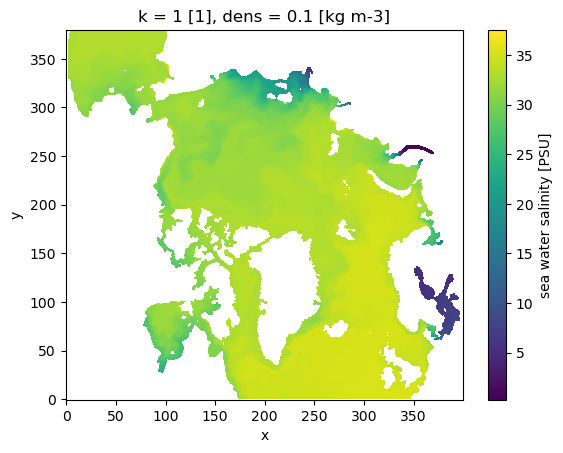

In [13]:
smean_lazy.plot()           # fast — already in memory

### `.compute()` — return a new in-memory object, original stays lazy

In [14]:
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
smean_lazy

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

In [15]:
smean = smean_lazy.compute()   # smean_lazy is still a Dask array

In [16]:
smean_lazy

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

In [17]:
smean

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B 0.1
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

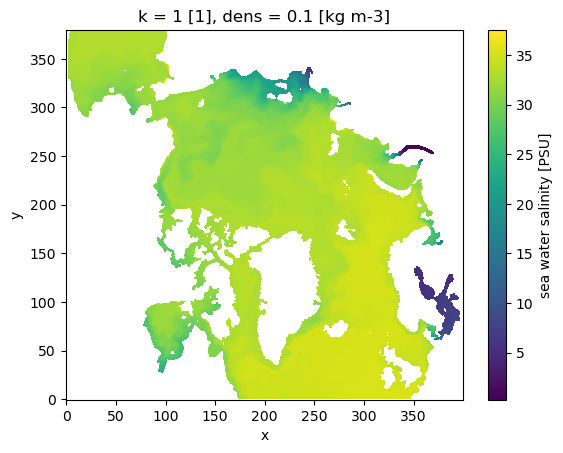

In [18]:
smean.plot()                   # fast

### `.plot()` — compute on the fly, result not stored

Use `.plot()` for quick inspection.  If you need the values afterwards, call `.load()` or `.compute()` first.

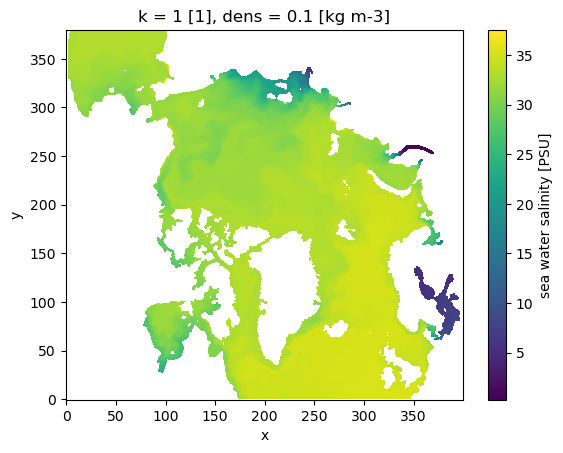

In [19]:
# .plot() computes internally — no need to load first
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
smean_lazy.plot()   # reads from disk, plots, discards the computed values

In [20]:
smean_lazy

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

### `.to_netcdf()` — compute and write to disk

In [21]:
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
smean_lazy.to_netcdf('smean_salin.nc')  # triggers full compute, writes result

In [22]:
smean_lazy

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

### `.values` — compute and return a NumPy array

In [23]:
smean_lazy = ds_lazy['salin'].isel(k=0).mean('time')
arr = smean_lazy.values   # plain NumPy array, e.g. for scipy / sklearn

In [24]:
smean_lazy

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

:::{tip}
Use `.load()` when you want to reuse a result multiple times — one disk read, then everything is fast.  Use `.compute()` when you want to keep a lazy original and hand a concrete copy to other code.
:::

## Putting it together for long time series

The same methods apply at any scale.  Here we compute the spatial-mean sea-surface height across 30 years and save it directly to NetCDF — Dask streams through the 11 805 files one chunk at a time.

In [25]:
%%time
%%memit

ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 28363.11 MiB, increment: 394.07 MiB
CPU times: user 8.67 s, sys: 247 ms, total: 8.92 s
Wall time: 8.96 s


In [26]:
ds_lazy

<xarray.Dataset> Size: 1TB
Dimensions:     (y: 380, x: 400, time: 366, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 3kB 2020-01-01 00:00:00 ... 2020-12-31 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 445MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

In [27]:
%%time
%%memit

sst_mean = ds_lazy.temp.isel(k=0).mean(dim=["y", "x"]).compute()

peak memory: 44266.91 MiB, increment: 15903.80 MiB
CPU times: user 19.7 s, sys: 9.59 s, total: 29.3 s
Wall time: 16.5 s


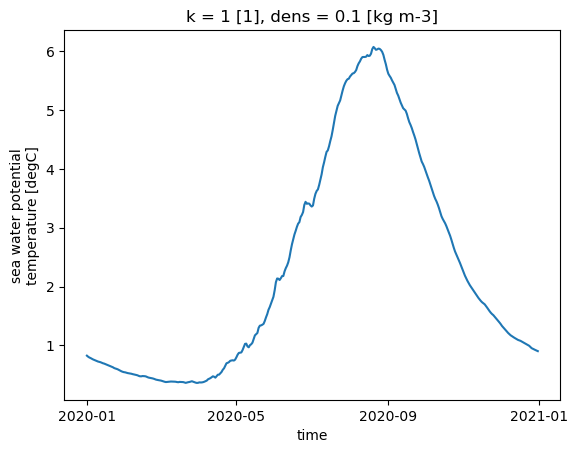

In [28]:
sst_mean.plot()

Finally, the full archive — every daily file from September 1992 to December 2024, covering over 30 years.

In [29]:
%%time
%%memit

ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 37898.73 MiB, increment: 7982.00 MiB
CPU times: user 4min 48s, sys: 7.24 s, total: 4min 55s
Wall time: 4min 50s


In [30]:
ds_lazy

<xarray.Dataset> Size: 38TB
Dimensions:     (y: 380, x: 400, time: 11805, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 94kB 1992-09-06 00:00:00 ... 2024-12-31 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

The Dataset spans **11,805 snapshots** (1992–2024) and represents **38 TB** of data on disk — none of which is in RAM yet.

The 8 GB memory increment is not field data: it is the Dask **task graph** — one deferred read task per variable per file. With 83 variables and 11,805 files that is roughly one million graph entries, each carrying the file path, record index, and function reference needed to read one array on demand. At ~8 KB of Python-object overhead per task, the graph itself costs gigabytes.

:::{tip}
You can shrink the graph by passing `variables=["temp", "salin", "srfhgt"]` (only
those fields are added to the graph) or by using larger time chunks
(`chunks={"time": 30}`, 30× fewer tasks). Both cut the task count substantially —
but, as the benchmark at the end of this notebook shows, the open time and memory
drop only ~2×, *not* in proportion to the task count: parsing the 11,805 `.b`
headers is a fixed cost neither option avoids.
:::

### Why the open call can be slow

With `chunks={"time": 1}` and many files, xhycom builds **one Dask task per variable per file**.  For a 30-year daily archive with 83 variables that is roughly **one million graph entries** — each a Python object carrying a file path, record index, and function reference.  At ~8 KB of overhead per task the graph alone costs gigabytes of RAM and takes minutes to construct.

There are two ways to shrink the graph:

#### Option A — larger time chunks

`chunks={"time": 1}` means one Dask task reads one file.  A larger value groups
multiple files into a single task, so the **task count** shrinks by that factor —
though, as the benchmark shows, the open time and graph memory fall much more
slowly than the task count does.

**Important:** this only works efficiently because xhycom builds the graph at
the requested granularity — it is *not* equivalent to opening with
`chunks={"time": 1}` and then calling `.rechunk()`, which would add a
second layer of tasks and make things worse.

| `chunks=` | tasks (83 vars, 11 805 files) | files read per task | graph memory (measured) |
|---|---|---|---|
| `{"time": 1}` | ~980 k | 1 | 8.0 GiB |
| `{"time": 30}` | ~33 k | 30 | 3.9 GiB |

A 30× drop in tasks buys only a ~2× drop in memory (and in open time): the fixed
cost of parsing every `.b` header dominates.  Choose a chunk size that fits your
typical access pattern.  If you always process a full month of daily data at once,
`{"time": 30}` is a natural choice — but note that accessing any single time step
will then cause Dask to read the entire 30-file chunk.

In [31]:
%%time
%%memit

# 30-day chunks: 30× fewer tasks, 30× smaller graph
ds_chunked = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH, chunks={"time": 30})

peak memory: 39152.85 MiB, increment: 3913.35 MiB
CPU times: user 2min 56s, sys: 4.96 s, total: 3min 1s
Wall time: 2min 58s


In [32]:
ds_chunked

<xarray.Dataset> Size: 38TB
Dimensions:     (y: 380, x: 400, time: 11805, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 94kB 1992-09-06 00:00:00 ... 2024-12-31 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 14GB dask.array<chunksize=(30, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

#### Option B — load only the variables you need

The `variables=` parameter limits which fields are included in the Dataset —
unneeded variables are never added to the Dask graph, which trims the task count
in proportion to the number of variables kept.  In practice, though, the open time
and graph memory fall much less than that (see the benchmark): parsing every file's
`.b` header is a fixed cost paid regardless of how many variables you request.

In [33]:
%%time
%%memit

# Only 3 variables → ~35 k tasks instead of ~980 k
ds_vars = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH, chunks={"time": 1}, variables=["temp", "salin", "srfhgt"])

peak memory: 40130.68 MiB, increment: 3639.16 MiB
CPU times: user 2min 32s, sys: 5.52 s, total: 2min 38s
Wall time: 2min 34s


In [34]:
ds_vars

<xarray.Dataset> Size: 1TB
Dimensions:  (y: 380, x: 400, time: 11805, k: 50)
Coordinates:
    lon      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time     (time) object 94kB 1992-09-06 00:00:00 ... 2024-12-31 00:00:00
  * k        (k) int64 400B 1 2 3 4 5 6 7 8 9 10 ... 42 43 44 45 46 47 48 49 50
    dens     (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    srfhgt   (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    temp     (time, k, y, x) float64 718GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    salin    (time, k, y, x) float64 718GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

You can also combine both options A and B — `variables=` with `chunks={"time": 30}` — to get the maximum reduction in graph size.

In [35]:
%%time
%%memit

ds_vars = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH, chunks={"time": 30}, variables=["temp", "salin", "srfhgt"])

peak memory: 40163.70 MiB, increment: 2694.00 MiB
CPU times: user 2min 26s, sys: 4.63 s, total: 2min 30s
Wall time: 2min 29s


In [36]:
%%time
%%memit

sst_mean = ds_lazy.temp.isel(k=0).mean(dim=["y", "x"]).compute()

peak memory: 49332.03 MiB, increment: 11830.49 MiB
CPU times: user 12min 5s, sys: 6min 28s, total: 18min 33s
Wall time: 9min 51s


- **Wall time: ~10 min** — streaming all 11,805 daily `.a` files to reduce surface temperature to a scalar time series. This is the same ~10 min you would get on 8 CPUs: the reduction is disk-bound, so the 256 cores here do not help (see the benchmark at the end of this notebook).
- **Increment: ~12 GiB** — *not* a single time step's worth. With 256 threads, Dask keeps hundreds of `temp` chunks in flight at once, and each `chunks={"time": 1}` block still holds all 50 layers (~60 MB). At a few cores the same reduction needs only a few hundred MiB — the streaming advantage is a low-core-count phenomenon.

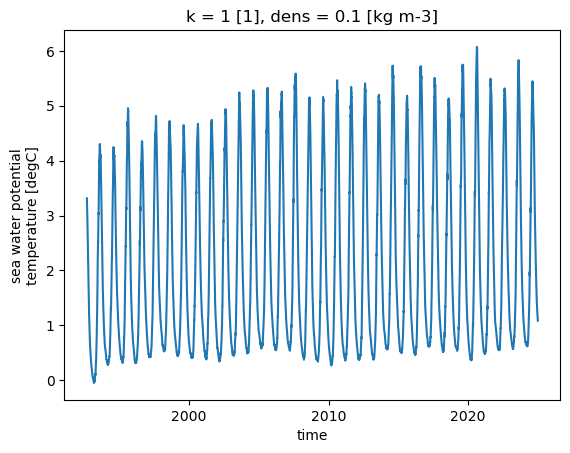

In [37]:
sst_mean.plot()

In [38]:
%%time
%%memit

ssh_mean = ds_lazy.srfhgt.mean(dim=["y", "x"]).compute()

peak memory: 37593.16 MiB, increment: 4.05 MiB
CPU times: user 2min 54s, sys: 15.3 s, total: 3min 10s
Wall time: 2min 34s


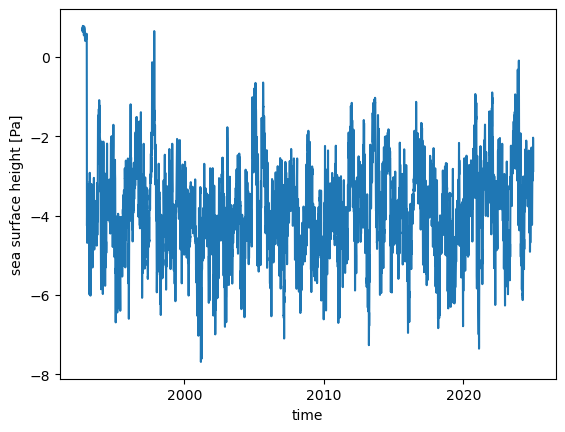

In [39]:
ssh_mean.plot()

## Benchmark: what scales with CPU count, and what doesn't

These cells were profiled on Olivia's `small` partition (`--partition=small` —
the Open OnDemand default, a shared partial-node allocation) at four core counts:
**1, 4, 8, and 256 CPUs**. Unless a row says otherwise, the data are opened with
the notebook's default lazy chunking — `chunks={"time": 1}` with the layer
dimension left whole (`k: -1`) — so each chunk is a single snapshot spanning all
50 layers. The headline result: **most of the cost does not come down with more
cores.** Only the read-bound `.compute()` reductions speed up, and only up to a
point — past which extra threads just consume more memory.

### Independent of CPU count — opening data

`open_mfdataset(..., chunks=...)` builds the Dask graph with serial Python work:
it parses one `.b` header per file and creates one task per variable per chunk.
Its wall time **and** its memory are set by the number of files and tasks, not by
the core count — across 1–256 CPUs both stayed within a few percent.

| Operation | Wall time | Memory increment |
|---|---|---|
| Open 9 files, **eager** (no `chunks`) | ~1 min 15 s | **53 GiB** |
| Open 9 files, lazy (`chunks={"time": 1}`) | ~0.5 s | ~90 MiB |
| Open 1 year, lazy (366 files) | ~9 s | ~400 MiB |
| Open full archive (11 805 files), `chunks={"time": 1}` | ~5 min | **8.0 GiB** |
| Open full archive, `chunks={"time": 30}` | ~3 min | 3.9 GiB |
| Open full archive, 3 vars, `chunks={"time": 1}` | ~2.7 min | 3.6 GiB |

The eager-vs-lazy contrast is the whole point of the tutorial: reading 9 files
into RAM costs **53 GiB and ~75 s**, while building the lazy graph for the same
data costs **~90 MiB and half a second** — and neither figure changes if you
request more CPUs.

### Depends on CPU count — streaming reductions

A `.compute()` reduction streams the `.a` binaries through Dask, which runs
independent chunks in parallel, so here extra cores help. But the speed-up
saturates quickly (the work is disk-bound), and past that point more threads only
**cost more memory**, because every in-flight chunk holds a data slab.

**Wall time**

| Operation | 1 CPU | 4 CPU | 8 CPU | 256 CPU |
|---|---|---|---|---|
| SST mean, full archive (`.compute()`) | 1 h 0 min | 13 min 8 s | 9 min 44 s | 9 min 51 s |
| SSH mean, full archive (`.compute()`) | 8 min 44 s | 2 min 37 s | 2 min 46 s | 2 min 34 s |

Most of the speed-up is already in hand by 4 cores; 8 → 256 buys **nothing** —
the reduction is limited by disk throughput, not CPU.

**Peak memory increment**

| Operation | 1 CPU | 4 CPU | 8 CPU | 256 CPU |
|---|---|---|---|---|
| SST mean — reads 3-D `temp` (50-layer chunks) | 70 MiB | 165 MiB | 308 MiB | **11.6 GiB** |
| SSH mean — reads 2-D `srfhgt` | 13 MiB | 4 MiB | 4 MiB | 4 MiB |

This is the catch: streaming is only memory-cheap at modest core counts. Because
the layer dimension is unchunked (`k: -1`), each `temp` chunk holds all 50 layers
(~60 MB), so at 256 threads ~200 chunks are resident at once → **11.6 GiB**. The
SSH mean reads 2-D `srfhgt` (~1 MB per chunk) and stays at a few MiB no matter the
core count. **For these reductions ~4–8 cores is the sweet spot** — 256 wastes the
allocation and risks running out of memory. (Chunking layers too —
`chunks={"time": 1, "k": 1}` — would shrink each slab 50× and tame the high-core
memory, at the cost of many more tasks.)

### Did requesting a subset of variables help? Not really.

`variables=["temp", "salin", "srfhgt"]` cuts the task count ~28× (≈980 k → ≈35 k),
yet the full-archive open only sped up from **~5 min → ~2.7 min** and graph memory
fell only from **8.0 GiB → 3.6 GiB** — barely **2×**, nowhere near the 28× the task
count implies. Opening is dominated by the **fixed** cost of parsing all 11 805
`.b` headers and assembling the `time` coordinate, which happens regardless of how
many variables you keep. Larger time chunks (`chunks={"time": 30}`) give a similar
~2× and stack with `variables=` (down to 2.6 GiB), but neither knob delivers
savings in proportion to the task count.

_Machine: Olivia compute node, `small` (shared) partition._

:::{note}
**Worth a follow-up.** This benchmark jumps straight from 8 to 256 CPUs, so the
whole transition is unmeasured: somewhere in that gap the wall-time speed-up flattens
out *and* peak memory starts to climb (the SST-mean increment runs from ~300 MiB at
8 CPUs to ~12 GiB at 256). Intermediate allocations — **16 / 32 / 64 CPUs** — would
pin down where the extra cores stop paying off and where the streaming reductions
begin to get memory-hungry, which is exactly the regime most users would actually
request. A small sensitivity sweep there would sharpen the "sweet spot" guidance
above.
:::